In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = "../data/EMG_data_for_gestures-master"

def load_all_subjects(root):
    all_dfs = []
    
    COLUMNS = [
        "time",
        "channel1","channel2","channel3","channel4",
        "channel5","channel6","channel7","channel8",
        "class"
    ]

    for subject in sorted(os.listdir(root)):
        subject_path = os.path.join(root, subject)
        if not os.path.isdir(subject_path):
            continue

        for file in sorted(os.listdir(subject_path)):
            if file.endswith(".txt"):
                df = pd.read_csv(
                    os.path.join(subject_path, file),
                    sep="\t",
                    header=None,
                    skiprows=1
                )
                df.columns = COLUMNS
                df["subject"] = subject
                all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

data = load_all_subjects(DATA_ROOT)

# Clean labels
data = data.dropna(subset=["class"])
data["class"] = data["class"].astype(int)

print("Total samples:", len(data))




Total samples: 4237907


In [2]:
# Step 2: Windowing (250 ms, majority vote)

CHANNELS = [
    "channel1","channel2","channel3","channel4",
    "channel5","channel6","channel7","channel8"
]

WINDOW_SIZE = 250
STEP_SIZE = 250  # non-overlapping

def window_per_subject(data):
    windows = []
    labels = []
    subjects = []

    for subject in np.unique(data["subject"]):
        df_sub = data[data["subject"] == subject]

        start = 0
        while start + WINDOW_SIZE <= len(df_sub):
            window = df_sub.iloc[start:start + WINDOW_SIZE]

            label = window["class"].mode()[0]

            windows.append(window[CHANNELS].values)
            labels.append(label)
            subjects.append(subject)

            start += WINDOW_SIZE

    return np.array(windows), np.array(labels), np.array(subjects)

X_w, y_w, subj_w = window_per_subject(data)

print("Total windows:", len(y_w))
print("Window shape:", X_w.shape)


Total windows: 16934
Window shape: (16934, 250, 8)


Window-level label counts:
0    10880
1     1004
2      980
3      997
4     1005
5     1005
6     1009
7       54
Name: count, dtype: int64


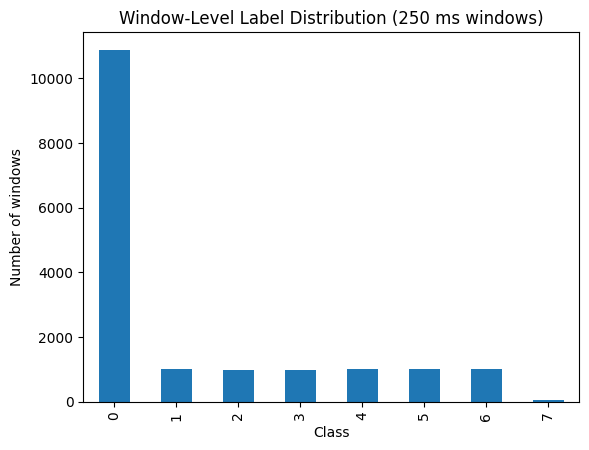

In [3]:
# Step 2.1: Window-level label distribution

import pandas as pd
import matplotlib.pyplot as plt

window_label_counts = pd.Series(y_w).value_counts().sort_index()

print("Window-level label counts:")
print(window_label_counts)

window_label_counts.plot(kind="bar")
plt.title("Window-Level Label Distribution (250 ms windows)")
plt.xlabel("Class")
plt.ylabel("Number of windows")
plt.show()


In [4]:
# Step 3: Define 2-class task (Rest vs Active)

# Keep only classes 1–6
mask_binary = np.isin(y_w, [1, 2, 3, 4, 5, 6])

X_bin = X_w[mask_binary]
y_bin_original = y_w[mask_binary]
subj_bin = subj_w[mask_binary]

# Relabel:
# 0 → Rest (original class 1)
# 1 → Active (original classes 2–6)
y_bin = np.where(y_bin_original == 1, 0, 1)

print("Total windows in binary task:", len(y_bin))

# Report class balance
class_counts = pd.Series(y_bin).value_counts().sort_index()
print("\nClass balance (Binary Task):")
print("0 (Rest):   ", class_counts.get(0, 0))
print("1 (Active): ", class_counts.get(1, 0))



Total windows in binary task: 6000

Class balance (Binary Task):
0 (Rest):    1004
1 (Active):  4996


In [5]:
# Step 4: Feature extraction (RMS + MAV)

def extract_rms_mav(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        mav = np.mean(np.abs(w), axis=0)
        features.append(np.concatenate([rms, mav]))
    return np.array(features)

X_bin_features = extract_rms_mav(X_bin)

print("Binary feature matrix shape:", X_bin_features.shape)


Binary feature matrix shape: (6000, 16)


In [6]:
# Step 5: Subject-wise split (binary task)

unique_subjects_bin = np.unique(subj_bin)
print("Total subjects:", len(unique_subjects_bin))
print("Subjects:", unique_subjects_bin)

# Hold out last 3 subjects for testing
test_subjects_bin = unique_subjects_bin[-3:]
print("Test subjects:", test_subjects_bin)

train_mask_bin = ~np.isin(subj_bin, test_subjects_bin)
test_mask_bin  =  np.isin(subj_bin, test_subjects_bin)

X_train_bin = X_bin_features[train_mask_bin]
y_train_bin = y_bin[train_mask_bin]

X_test_bin  = X_bin_features[test_mask_bin]
y_test_bin  = y_bin[test_mask_bin]

print("\nTrain samples:", len(y_train_bin))
print("Test samples :", len(y_test_bin))


Total subjects: 36
Subjects: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '15' '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '30' '31' '32' '33' '34' '35' '36']
Test subjects: ['34' '35' '36']

Train samples: 5515
Test samples : 485


In [7]:
# Step 6: Scaling (binary task)

from sklearn.preprocessing import StandardScaler

scaler_bin = StandardScaler()

X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled  = scaler_bin.transform(X_test_bin)

print("Scaled train mean (first 5 features):", X_train_bin_scaled.mean(axis=0)[:5])
print("Scaled train std  (first 5 features):", X_train_bin_scaled.std(axis=0)[:5])



Scaled train mean (first 5 features): [-1.38794989e-15  3.54037339e-15  4.18381960e-15 -4.52991125e-15
 -7.45168005e-16]
Scaled train std  (first 5 features): [1. 1. 1. 1. 1.]


In [8]:
# Step 7: Train binary Logistic Regression

from sklearn.linear_model import LogisticRegression

clf_bin = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1
)

clf_bin.fit(X_train_bin_scaled, y_train_bin)

print("Binary Logistic Regression training complete.")


Binary Logistic Regression training complete.


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [9]:
# Step 8: Evaluation (binary task)

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_bin = clf_bin.predict(X_test_bin_scaled)

accuracy_bin = accuracy_score(y_test_bin, y_pred_bin)
macro_f1_bin = f1_score(y_test_bin, y_pred_bin, average="macro")
precision_bin = precision_score(y_test_bin, y_pred_bin)
recall_bin = recall_score(y_test_bin, y_pred_bin)

print(f"Accuracy      : {accuracy_bin:.4f}")
print(f"Macro F1      : {macro_f1_bin:.4f}")
print(f"Precision     : {precision_bin:.4f}")
print(f"Recall        : {recall_bin:.4f}")


Accuracy      : 0.9979
Macro F1      : 0.9963
Precision     : 1.0000
Recall        : 0.9975



Classification Report (Binary Task):
              precision    recall  f1-score   support

    Rest (0)       0.99      1.00      0.99        82
  Active (1)       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       0.99      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485



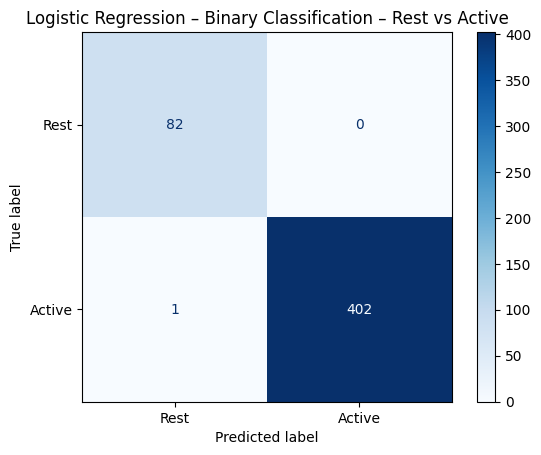

In [10]:
# Step 9: Binary Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


LR_report = classification_report(y_test_bin, y_pred_bin, target_names=["Rest (0)", "Active (1)"])
print("\nClassification Report (Binary Task):")
print(LR_report)

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["Rest", "Active"])

disp_bin.plot(cmap="Blues")
plt.title("Logistic Regression – Binary Classification – Rest vs Active")
plt.show()


In [11]:
# SVM
from sklearn.svm import SVC
clf_svm_bin = SVC(
    kernel="rbf",
    class_weight="balanced",
    max_iter=1000
)

clf_svm_bin.fit(X_train_bin_scaled, y_train_bin)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
y_pred_svm_bin = clf_svm_bin.predict(X_test_bin_scaled)
accuracy_svm_bin = accuracy_score(y_test_bin, y_pred_svm_bin)
macro_f1_svm_bin = f1_score(y_test_bin, y_pred_svm_bin, average="macro")
precision_svm_bin = precision_score(y_test_bin, y_pred_svm_bin)
recall_svm_bin = recall_score(y_test_bin, y_pred_svm_bin)
print(f"SVM Accuracy      : {accuracy_svm_bin:.4f}")
print(f"SVM Macro F1      : {macro_f1_svm_bin:.4f}")
print(f"SVM Precision     : {precision_svm_bin:.4f}")
print(f"SVM Recall        : {recall_svm_bin:.4f}")


SVM Accuracy      : 0.9959
SVM Macro F1      : 0.9927
SVM Precision     : 1.0000
SVM Recall        : 0.9950


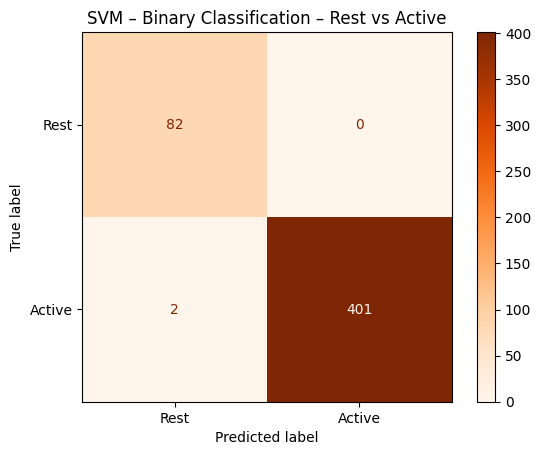

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cmm = confusion_matrix(y_test_bin, y_pred_svm_bin)
disp_svm_bin = ConfusionMatrixDisplay(confusion_matrix=cmm, display_labels=["Rest", "Active"])

disp_svm_bin.plot(cmap="Oranges")
plt.title("SVM – Binary Classification – Rest vs Active")
plt.show()

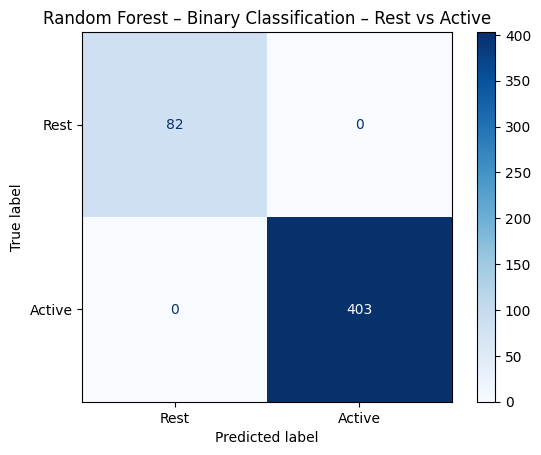

Random Forest Accuracy: 1.0000
Random Forest Macro F1: 1.0000
Random Forest Precision: 1.0000
Random Forest Recall: 1.0000
Confusion Matrix:
[[ 82   0]
 [  0 403]]
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       1.00      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485



In [14]:
#  Random Forest 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
rf_model_bin = RandomForestClassifier(n_estimators=20, random_state=42)
rf_model_bin.fit(X_train_bin_scaled, y_train_bin)
y_pred_rf_bin = rf_model_bin.predict(X_test_bin_scaled)
accuracy_rf_bin = accuracy_score(y_test_bin, y_pred_rf_bin)
f1_rf_bin = f1_score(y_test_bin, y_pred_rf_bin, average="macro")
precision_rf_bin = precision_score(y_test_bin, y_pred_rf_bin)
recall_rf_bin = recall_score(y_test_bin, y_pred_rf_bin)
cm_rf_bin = confusion_matrix(y_test_bin, y_pred_rf_bin)
disp_rf_bin = ConfusionMatrixDisplay(confusion_matrix=cm_rf_bin, display_labels=["Rest", "Active"])
disp_rf_bin.plot(cmap="Blues")
plt.title("Random Forest – Binary Classification – Rest vs Active")
plt.show()
report_rf_bin = classification_report(y_test_bin, y_pred_rf_bin)

print(f"Random Forest Accuracy: {accuracy_rf_bin:.4f}")
print(f"Random Forest Macro F1: {f1_rf_bin:.4f}")
print(f"Random Forest Precision: {precision_rf_bin:.4f}")
print(f"Random Forest Recall: {recall_rf_bin:.4f}")
print(f"Confusion Matrix:\n{cm_rf_bin}")
print(f"Random Forest Classification Report:\n{report_rf_bin}")


Random Forest got highest accuracy amoung all other models and that is 100%

KNN Accuracy: 1.0000
KNN Macro F1: 1.0000
KNN Precision: 1.0000
KNN Recall: 1.0000
KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       1.00      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485

Confusion Matrix:
[[ 82   0]
 [  0 403]]


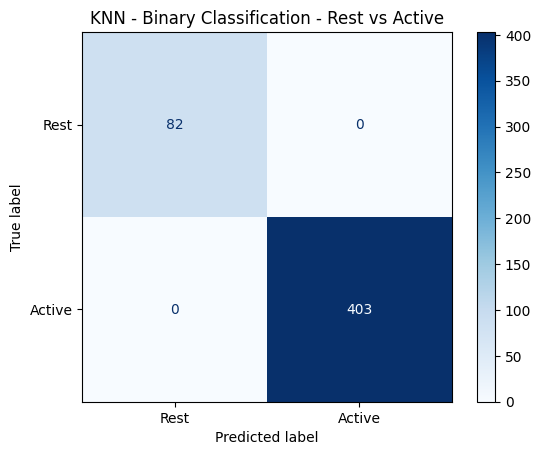

In [15]:
# knn
from sklearn.neighbors import KNeighborsClassifier
knn_model_bin = KNeighborsClassifier(n_neighbors=5)
knn_model_bin.fit(X_train_bin_scaled, y_train_bin)
y_pred_knn_bin = knn_model_bin.predict(X_test_bin_scaled)
accuracy_knn_bin = accuracy_score(y_test_bin, y_pred_knn_bin)
f1_knn_bin = f1_score(y_test_bin, y_pred_knn_bin, average="macro")
precision_knn_bin = precision_score(y_test_bin, y_pred_knn_bin)
recall_knn_bin = recall_score(y_test_bin, y_pred_knn_bin)
report_knn_bin = classification_report(y_test_bin, y_pred_knn_bin)
cm_knn_bin = confusion_matrix(y_test_bin, y_pred_knn_bin)
print(f"KNN Accuracy: {accuracy_knn_bin:.4f}")
print(f"KNN Macro F1: {f1_knn_bin:.4f}")
print(f"KNN Precision: {precision_knn_bin:.4f}")
print(f"KNN Recall: {recall_knn_bin:.4f}")
print(f"KNN Classification Report:\n{report_knn_bin}")
print(f"Confusion Matrix:\n{cm_knn_bin}")

disp_knn_bin = ConfusionMatrixDisplay(confusion_matrix=cm_knn_bin, display_labels=["Rest", "Active"])
disp_knn_bin.plot(cmap="Blues")
plt.title("KNN - Binary Classification - Rest vs Active")
plt.show()

In [16]:
# Step 11: Verify scaling protocol (no data leakage)

print("Feature Scaling Verification")

print("\nScaler was fit ONLY on training data:")
print("X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)")

print("\nTest data was ONLY transformed using the same scaler:")
print("X_test_bin_scaled = scaler_bin.transform(X_test_bin)")

print("\nThis ensures that information from test subjects was NOT used during training.")
print("Therefore, there is no data leakage in the feature scaling step.")

Feature Scaling Verification

Scaler was fit ONLY on training data:
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)

Test data was ONLY transformed using the same scaler:
X_test_bin_scaled = scaler_bin.transform(X_test_bin)

This ensures that information from test subjects was NOT used during training.
Therefore, there is no data leakage in the feature scaling step.


In [17]:
# Step 11: Verify scaling protocol (check for data leakage)

print("=== Feature Scaling Verification ===")

# Training statistics
train_mean = X_train_bin_scaled.mean(axis=0)
train_std = X_train_bin_scaled.std(axis=0)

# Test statistics
test_mean = X_test_bin_scaled.mean(axis=0)
test_std = X_test_bin_scaled.std(axis=0)

print("\nTrain feature mean (first 5 features):")
print(train_mean[:5])

print("\nTrain feature std (first 5 features):")
print(train_std[:5])

print("\nTest feature mean (first 5 features):")
print(test_mean[:5])

print("\nTest feature std (first 5 features):")
print(test_std[:5])


print("\n=== Interpretation ===")

print("If feature scaling leakage had occurred (for example, using scaler.fit(train + test)),")
print("then BOTH training and test data would have mean ≈ 0 and std ≈ 1.")

print("\nObserved results:")
print("Training data: mean ≈ 0 and std ≈ 1 (because the scaler was fit on training data).")
print("Test data    : mean ≠ 0 and std ≠ 1 (because test data was only transformed).")

print("\nConclusion:")
print("The scaler was fit strictly on the training data and then applied to the test data.")
print("Therefore, there is NO feature scaling leakage.")

=== Feature Scaling Verification ===

Train feature mean (first 5 features):
[-1.38794989e-15  3.54037339e-15  4.18381960e-15 -4.52991125e-15
 -7.45168005e-16]

Train feature std (first 5 features):
[1. 1. 1. 1. 1.]

Test feature mean (first 5 features):
[ 0.06103985 -0.02541617 -0.40300082 -0.38773354  0.04730212]

Test feature std (first 5 features):
[1.11649    0.97275553 0.41240944 0.68284921 1.0497793 ]

=== Interpretation ===
If feature scaling leakage had occurred (for example, using scaler.fit(train + test)),
then BOTH training and test data would have mean ≈ 0 and std ≈ 1.

Observed results:
Training data: mean ≈ 0 and std ≈ 1 (because the scaler was fit on training data).
Test data    : mean ≠ 0 and std ≠ 1 (because test data was only transformed).

Conclusion:
The scaler was fit strictly on the training data and then applied to the test data.
Therefore, there is NO feature scaling leakage.


In [18]:
# Step 12: Feature extraction variants for ablation study

def extract_rms(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        features.append(rms)
    return np.array(features)


def extract_mav(windows):
    features = []
    for w in windows:
        mav = np.mean(np.abs(w), axis=0)
        features.append(mav)
    return np.array(features)


def extract_rms_mav(windows):
    features = []
    for w in windows:
        rms = np.sqrt(np.mean(w ** 2, axis=0))
        mav = np.mean(np.abs(w), axis=0)
        features.append(np.concatenate([rms, mav]))
    return np.array(features)


# Generate feature sets
X_rms = extract_rms(X_bin)
X_mav = extract_mav(X_bin)
X_rms_mav = extract_rms_mav(X_bin)

print("Feature shapes:")
print("RMS only:", X_rms.shape)
print("MAV only:", X_mav.shape)
print("RMS + MAV:", X_rms_mav.shape)

Feature shapes:
RMS only: (6000, 8)
MAV only: (6000, 8)
RMS + MAV: (6000, 16)


In [19]:
# Step 13: Function to train and evaluate a feature set (for ablation study)

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

def evaluate_feature_set(X_features, y, subjects):

    # same subject-wise split
    train_mask = ~np.isin(subjects, test_subjects_bin)
    test_mask = np.isin(subjects, test_subjects_bin)

    X_train = X_features[train_mask]
    X_test = X_features[test_mask]

    y_train = y[train_mask]
    y_test = y[test_mask]

    # scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model (same baseline model)
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro")

    return acc, f1

In [20]:
# Step 14: Run ablation study with full classification reports

from sklearn.metrics import classification_report

def run_ablation(X_features, feature_name):

    # subject-wise split
    train_mask = ~np.isin(subj_bin, test_subjects_bin)
    test_mask = np.isin(subj_bin, test_subjects_bin)

    X_train = X_features[train_mask]
    X_test = X_features[test_mask]

    y_train = y_bin[train_mask]
    y_test = y_bin[test_mask]

    # scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # model
    clf = LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    print("\n==============================")
    print(f"Ablation Result: {feature_name}")
    print("==============================")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Run ablation experiments
run_ablation(X_rms, "RMS Only")
run_ablation(X_mav, "MAV Only")
run_ablation(X_rms_mav, "RMS + MAV")


Ablation Result: RMS Only

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       0.99      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485


Ablation Result: MAV Only

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       403

    accuracy                           1.00       485
   macro avg       0.99      1.00      1.00       485
weighted avg       1.00      1.00      1.00       485


Ablation Result: RMS + MAV

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       1.00      1.00      1.00       403

    accuracy                

In [21]:
# Step 15: Prepare multi-class dataset (gestures 1–6)

mask_multi = np.isin(y_w, [1,2,3,4,5,6])

X_multi = X_w[mask_multi]
y_multi = y_w[mask_multi]
subj_multi = subj_w[mask_multi]

print("Total windows in multi-class task:", len(y_multi))
print("\nClass distribution:")

import pandas as pd
print(pd.Series(y_multi).value_counts().sort_index())

Total windows in multi-class task: 6000

Class distribution:
1    1004
2     980
3     997
4    1005
5    1005
6    1009
Name: count, dtype: int64


In [22]:
# Step 16: Feature extraction for multi-class task (RMS + MAV)

X_multi_features = extract_rms_mav(X_multi)

print("Multi-class feature matrix shape:", X_multi_features.shape)

Multi-class feature matrix shape: (6000, 16)


In [23]:
# Step 17: Subject-wise split for multi-class task

unique_subjects_multi = np.unique(subj_multi)

print("Total subjects:", len(unique_subjects_multi))
print("Subjects:", unique_subjects_multi)

# Hold out last 3 subjects for testing (same protocol as binary)
test_subjects_multi = unique_subjects_multi[-3:]

print("\nTest subjects:", test_subjects_multi)

train_mask_multi = ~np.isin(subj_multi, test_subjects_multi)
test_mask_multi = np.isin(subj_multi, test_subjects_multi)

X_train_multi = X_multi_features[train_mask_multi]
y_train_multi = y_multi[train_mask_multi]

X_test_multi = X_multi_features[test_mask_multi]
y_test_multi = y_multi[test_mask_multi]

print("\nTrain samples:", len(y_train_multi))
print("Test samples :", len(y_test_multi))

Total subjects: 36
Subjects: ['01' '02' '03' '04' '05' '06' '07' '08' '09' '10' '11' '12' '13' '14'
 '15' '16' '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28'
 '29' '30' '31' '32' '33' '34' '35' '36']

Test subjects: ['34' '35' '36']

Train samples: 5515
Test samples : 485


In [24]:
print(X_train_multi.shape)


(5515, 16)


In [25]:
# Step 18: Scaling for multi-class task (no data leakage)

from sklearn.preprocessing import StandardScaler

scaler_multi = StandardScaler()

# Fit only on training data
X_train_multi_scaled = scaler_multi.fit_transform(X_train_multi)

# Apply same scaler to test data
X_test_multi_scaled = scaler_multi.transform(X_test_multi)

print("Scaled train mean (first 5 features):",
      X_train_multi_scaled.mean(axis=0)[:5])

print("Scaled train std (first 5 features):",
      X_train_multi_scaled.std(axis=0)[:5])

Scaled train mean (first 5 features): [-1.38794989e-15  3.54037339e-15  4.18381960e-15 -4.52991125e-15
 -7.45168005e-16]
Scaled train std (first 5 features): [1. 1. 1. 1. 1.]


In [26]:
# Step 19: Train multi-class Logistic Regression

from sklearn.linear_model import LogisticRegression

clf_multi = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    n_jobs=-1
)

clf_multi.fit(X_train_multi_scaled, y_train_multi)

print("Multi-class Logistic Regression training complete.")

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Multi-class Logistic Regression training complete.


=== Multi-class Results ===

Accuracy : 0.8845360824742268
Macro F1 : 0.8840924062096857

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        82
           2       1.00      0.80      0.89        81
           3       0.72      0.99      0.84        80
           4       0.93      0.81      0.87        81
           5       0.91      0.94      0.92        83
           6       0.82      0.76      0.79        78

    accuracy                           0.88       485
   macro avg       0.90      0.88      0.88       485
weighted avg       0.90      0.88      0.89       485



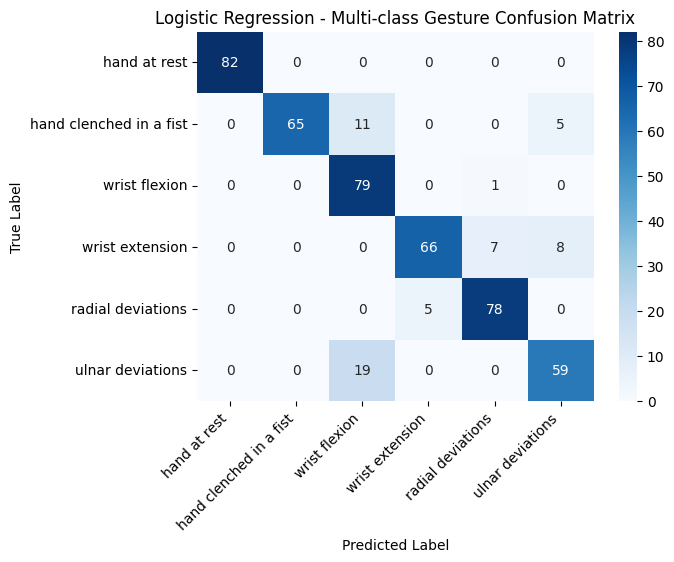

In [27]:
# Step 20: Multi-class evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred_multi = clf_multi.predict(X_test_multi_scaled)

# Metrics
accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
macro_f1_multi = f1_score(y_test_multi, y_pred_multi, average="macro")

print("=== Multi-class Results ===")

print("\nAccuracy :", accuracy_multi)
print("Macro F1 :", macro_f1_multi)

print("\nClassification Report:")
print(classification_report(y_test_multi, y_pred_multi))

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

class_names = [
    "hand at rest",
    "hand clenched in a fist",
    "wrist flexion",
    "wrist extension",
    "radial deviations",
    "ulnar deviations"
]

sns.heatmap(
    cm_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.title("Logistic Regression - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

KNN Accuracy: 0.8639
KNN Macro F1: 0.8628
KNN Precision: 0.8657
KNN Recall: 0.8632


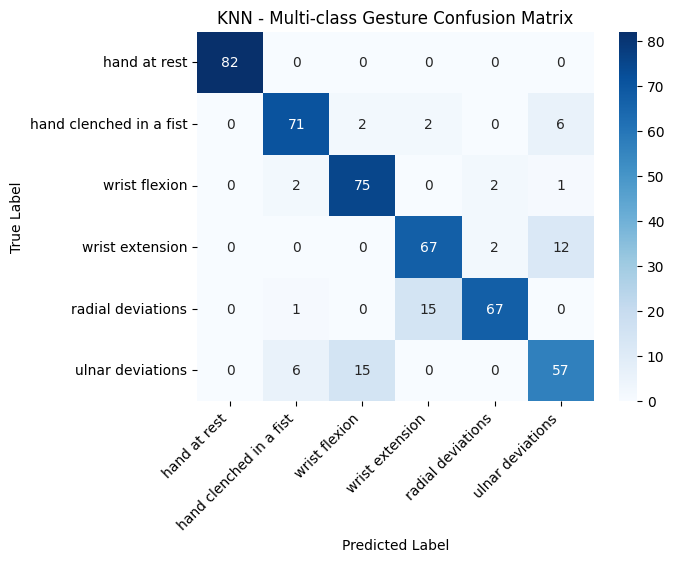

In [28]:
#21 Train multi-class 
from sklearn.neighbors import KNeighborsClassifier
knn_multi = KNeighborsClassifier(n_neighbors=5)
knn_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_knn_multi = knn_multi.predict(X_test_multi_scaled)
accuracy_knn_multi = accuracy_score(y_test_multi, y_pred_knn_multi)
f1_knn_multi = f1_score(y_test_multi, y_pred_knn_multi, average="macro")
precision_knn_multi = precision_score(y_test_multi, y_pred_knn_multi, average="macro")
recall_knn_multi = recall_score(y_test_multi, y_pred_knn_multi, average="macro")

print(f"KNN Accuracy: {accuracy_knn_multi:.4f}")
print(f"KNN Macro F1: {f1_knn_multi:.4f}")
print(f"KNN Precision: {precision_knn_multi:.4f}")
print(f"KNN Recall: {recall_knn_multi:.4f}")

cm_knn_multi = confusion_matrix(y_test_multi, y_pred_knn_multi)
class_names = [
    "hand at rest",
    "hand clenched in a fist",
    "wrist flexion",
    "wrist extension",
    "radial deviations",
    "ulnar deviations"
]

sns.heatmap(
    cm_knn_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("KNN - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM Accuracy      : 0.8701
SVM Macro F1      : 0.8700
SVM Precision     : 0.8803
SVM Recall        : 0.8691


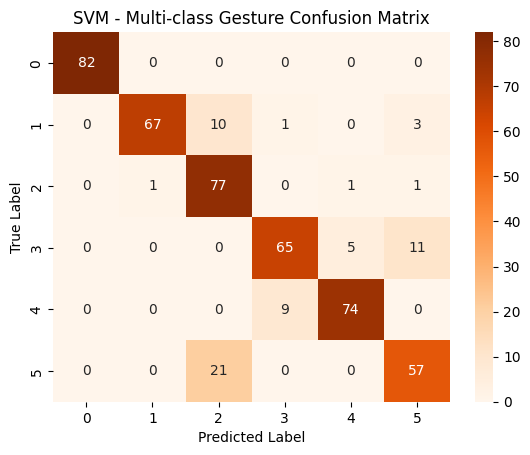

In [29]:
svm_multi = SVC(kernel="rbf", class_weight="balanced", max_iter=1000)
svm_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_svm_multi = svm_multi.predict(X_test_multi_scaled)
accuracy_svm_multi = accuracy_score(y_test_multi, y_pred_svm_multi)
f1_svm_multi = f1_score(y_test_multi, y_pred_svm_multi, average="macro")
precision_svm_multi = precision_score(y_test_multi, y_pred_svm_multi, average="macro")
recall_svm_multi = recall_score(y_test_multi, y_pred_svm_multi, average="macro")
print(f"SVM Accuracy      : {accuracy_svm_multi:.4f}")
print(f"SVM Macro F1      : {f1_svm_multi:.4f}")

print(f"SVM Precision     : {precision_svm_multi:.4f}")
print(f"SVM Recall        : {recall_svm_multi:.4f}")

cm_svm_multi = confusion_matrix(y_test_multi, y_pred_svm_multi)
sns.heatmap(cm_svm_multi, annot=True, fmt="d", cmap="Oranges")
plt.title("SVM - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

GaussianNB Accuracy      : 0.7340
GaussianNB Macro F1      : 0.7249
GaussianNB Precision     : 0.7478
GaussianNB Recall        : 0.7322


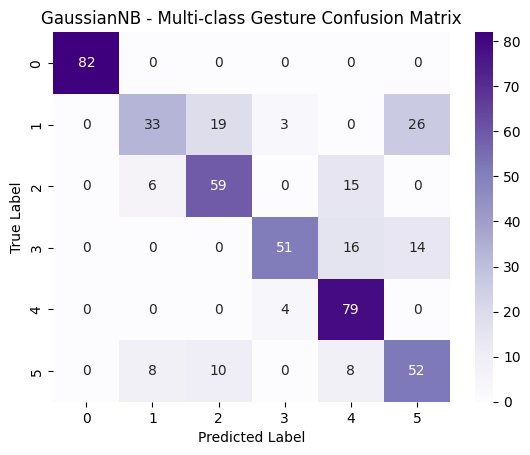

In [30]:
from sklearn.naive_bayes import GaussianNB
gnb_multi = GaussianNB()
gnb_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_gnb_multi = gnb_multi.predict(X_test_multi_scaled)
accuracy_gnb_multi = accuracy_score(y_test_multi, y_pred_gnb_multi)
f1_gnb_multi = f1_score(y_test_multi, y_pred_gnb_multi, average="macro")
precision_gnb_multi = precision_score(y_test_multi, y_pred_gnb_multi, average="macro")
recall_gnb_multi = recall_score(y_test_multi, y_pred_gnb_multi, average="macro")
print(f"GaussianNB Accuracy      : {accuracy_gnb_multi:.4f}")
print(f"GaussianNB Macro F1      : {f1_gnb_multi:.4f}")
print(f"GaussianNB Precision     : {precision_gnb_multi:.4f}")
print(f"GaussianNB Recall        : {recall_gnb_multi:.4f}")
cm_gnb_multi = confusion_matrix(y_test_multi, y_pred_gnb_multi)
sns.heatmap(cm_gnb_multi, annot=True, fmt="d", cmap="Purples")
plt.title("GaussianNB - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Random Forest Accuracy: 0.8845
Random Forest Macro F1: 0.8827
Random Forest Precision: 0.8911
Random Forest Recall: 0.8834
Random Forest Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        82
           2       1.00      0.96      0.98        81
           3       0.75      0.99      0.85        80
           4       0.83      0.83      0.83        81
           5       0.96      0.84      0.90        83
           6       0.82      0.68      0.74        78

    accuracy                           0.88       485
   macro avg       0.89      0.88      0.88       485
weighted avg       0.89      0.88      0.88       485



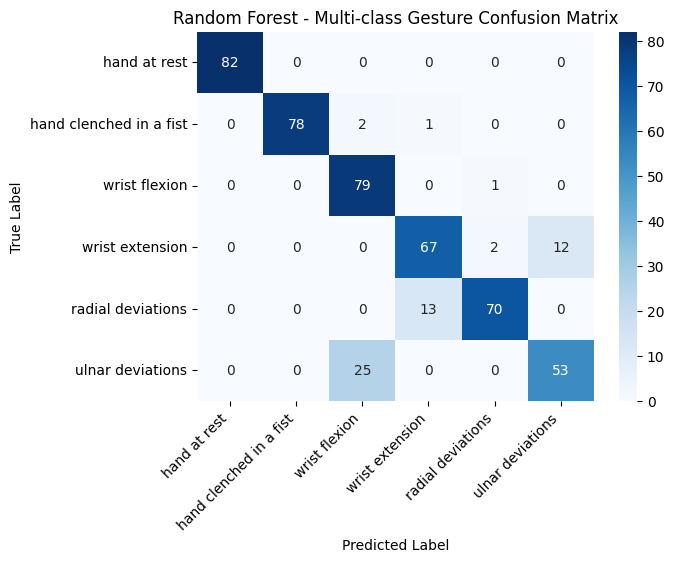

In [31]:
from sklearn.ensemble import RandomForestClassifier
rf_multi = RandomForestClassifier(n_estimators=20, random_state=42)
rf_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_rf_multi = rf_multi.predict(X_test_multi_scaled)
accuracy_rf_multi = accuracy_score(y_test_multi, y_pred_rf_multi)
f1_rf_multi = f1_score(y_test_multi, y_pred_rf_multi, average="macro")
precision_rf_multi = precision_score(y_test_multi, y_pred_rf_multi, average="macro")
recall_rf_multi = recall_score(y_test_multi, y_pred_rf_multi, average="macro")
print(f"Random Forest Accuracy: {accuracy_rf_multi:.4f}")
print(f"Random Forest Macro F1: {f1_rf_multi:.4f}")
print(f"Random Forest Precision: {precision_rf_multi:.4f}")
print(f"Random Forest Recall: {recall_rf_multi:.4f}")
cm_rf_multi = confusion_matrix(y_test_multi, y_pred_rf_multi)

report_rf_multi = classification_report(y_test_multi, y_pred_rf_multi)
print(f"Random Forest Classification Report:\n{report_rf_multi}")

sns.heatmap(
    cm_rf_multi,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Random Forest - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Decision Tree Accuracy: 0.8309
Decision Tree Macro F1: 0.8277
Decision Tree Precision: 0.8364
Decision Tree Recall: 0.8296


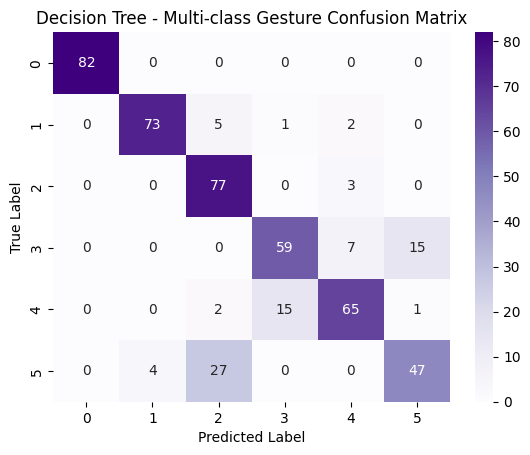

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt_multi = DecisionTreeClassifier(random_state=42)
dt_multi.fit(X_train_multi_scaled, y_train_multi)
y_pred_dt_multi = dt_multi.predict(X_test_multi_scaled)
accuracy_dt_multi = accuracy_score(y_test_multi, y_pred_dt_multi)
f1_dt_multi = f1_score(y_test_multi, y_pred_dt_multi, average="macro")
precision_dt_multi = precision_score(y_test_multi, y_pred_dt_multi, average="macro")
recall_dt_multi = recall_score(y_test_multi, y_pred_dt_multi, average="macro")
print(f"Decision Tree Accuracy: {accuracy_dt_multi:.4f}")
print(f"Decision Tree Macro F1: {f1_dt_multi:.4f}")
print(f"Decision Tree Precision: {precision_dt_multi:.4f}")
print(f"Decision Tree Recall: {recall_dt_multi:.4f}")
cm_dt_multi = confusion_matrix(y_test_multi, y_pred_dt_multi)
sns.heatmap(cm_dt_multi, annot=True, fmt="d", cmap="Purples")
plt.title("Decision Tree - Multi-class Gesture Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()